To Learn more about dataset-
*https://github.com/HoaNP/NSL-KDD-DataSet*

#### Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

ModuleNotFoundError: No module named 'pandas'

In [ ]:
train = pd.read_csv("/content/KDDTest.txt", header=None)
test  = pd.read_csv("/content/KDDTrain.txt", header=None)

#### Common Pre-Processing

In [ ]:
feature_names = [
 'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
 'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
 'root_shell','su_attempted','num_root','num_file_creations','num_shells',
 'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
 'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
 'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
 'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
 'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
 'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate'
]

cols = feature_names + ['label', 'difficulty']

train = pd.read_csv('/content/KDDTest.txt', names=cols)
test  = pd.read_csv('/content/KDDTrain.txt',  names=cols)

In [ ]:
train.drop('difficulty', inplace=True, axis=1)
test.drop('difficulty', inplace=True, axis=1)

In [ ]:
train['binary_label'] = train['label'].apply(lambda x: 0 if x.strip()=='normal' else 1)
test['binary_label']  = test['label'].apply(lambda x: 0 if x.strip()=='normal' else 1)

In [ ]:
# Map the many specific labels to 5 main categories
attack_dict = {
    'normal': 'normal',
    'back': 'dos', 'land': 'dos', 'neptune': 'dos', 'pod': 'dos', 'smurf': 'dos', 'teardrop': 'dos', 'mailbomb': 'dos', 'apache2': 'dos', 'processtable': 'dos', 'udpstorm': 'dos',
    'ipsweep': 'probe', 'nmap': 'probe', 'portsweep': 'probe', 'satan': 'probe', 'mscan': 'probe', 'saint': 'probe',
    'ftp_write': 'r2l', 'guess_passwd': 'r2l', 'imap': 'r2l', 'multihop': 'r2l', 'phf': 'r2l', 'spy': 'r2l', 'warezclient': 'r2l', 'warezmaster': 'r2l', 'sendmail': 'r2l', 'named': 'r2l', 'snmpgetattack': 'r2l', 'snmpguess': 'r2l', 'xlock': 'r2l', 'xsnoop': 'r2l', 'httptunnel': 'r2l',
    'buffer_overflow': 'u2r', 'loadmodule': 'u2r', 'perl': 'u2r', 'rootkit': 'u2r', 'xterm': 'u2r', 'ps': 'u2r', 'sqlattack': 'u2r'
}

# Apply grouping (Replace the binary_label logic in your notebook)
train['attack_type'] = train['label'].str.strip().map(attack_dict)
test['attack_type'] = test['label'].str.strip().map(attack_dict)

# Encode these into numbers (0-4)
le = LabelEncoder()
train['target'] = le.fit_transform(train['attack_type'])
test['target'] = le.transform(test['attack_type'])
train.drop('label', inplace=True, axis=1)
test.drop('label', inplace=True, axis=1)

#### Training Data Pre-Processing

In [ ]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,binary_label
0,13,tcp,telnet,SF,118,2425,0,0,0,0,...,0.38,0.12,0.04,0.0,0.00,0.00,0.12,0.3,guess_passwd,1
1,0,udp,private,SF,44,0,0,0,0,0,...,1.00,0.01,0.01,0.0,0.00,0.00,0.00,0.0,snmpguess,1
2,0,tcp,telnet,S3,0,44,0,0,0,0,...,0.31,0.61,0.00,0.0,0.21,0.68,0.60,0.0,processtable,1
3,0,udp,private,SF,53,55,0,0,0,0,...,1.00,0.00,0.87,0.0,0.00,0.00,0.00,0.0,normal,0
4,0,tcp,private,SH,0,0,0,0,0,0,...,0.06,1.00,1.00,0.0,1.00,1.00,0.00,0.0,nmap,1


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11850 entries, 0 to 11849
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     11850 non-null  int64  
 1   protocol_type                11850 non-null  object 
 2   service                      11850 non-null  object 
 3   flag                         11850 non-null  object 
 4   src_bytes                    11850 non-null  int64  
 5   dst_bytes                    11850 non-null  int64  
 6   land                         11850 non-null  int64  
 7   wrong_fragment               11850 non-null  int64  
 8   urgent                       11850 non-null  int64  
 9   hot                          11850 non-null  int64  
 10  num_failed_logins            11850 non-null  int64  
 11  logged_in                    11850 non-null  int64  
 12  num_compromised              11850 non-null  int64  
 13  root_shell      

In [ ]:
train.isnull().sum()        # NO NULL values, Therefore No IMPUTATIONS required...

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [ ]:
vals = train['protocol_type'].value_counts()
vals

,count
protocol_type,
tcp,8632
udp,2238
icmp,980


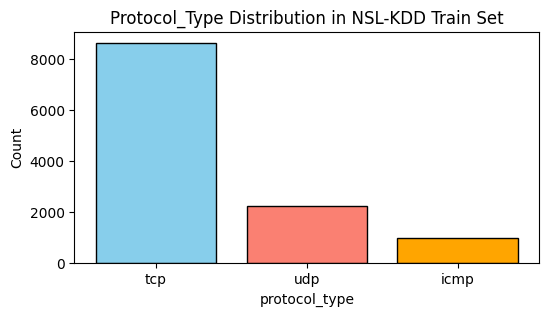

In [ ]:
cat = train['protocol_type'].unique()
plt.figure(figsize=(6,3))
plt.bar(cat, vals, color=['skyblue','salmon', 'orange'], edgecolor = 'black')
plt.title('Protocol_Type Distribution in NSL-KDD Train Set')
plt.xlabel('protocol_type')
plt.ylabel('Count')
plt.show()

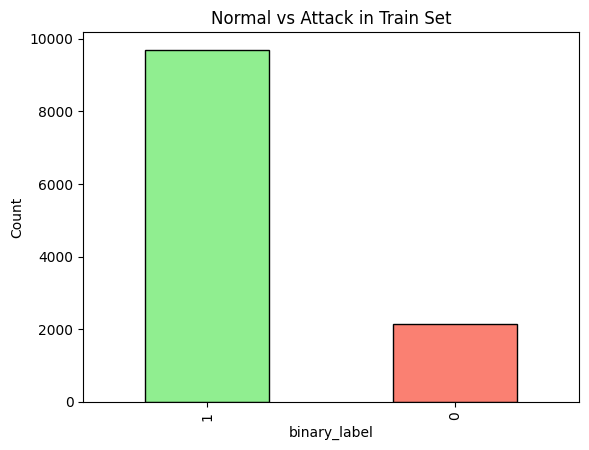

In [ ]:
train['binary_label'].value_counts().plot(kind='bar', color=['lightgreen','salmon'], edgecolor = 'black')
plt.title('Normal vs Attack in Train Set')
plt.ylabel('Count')
plt.show()


##### Since your target (normal vs attack) is well balanced, the feature-level imbalance in protocol_type (tcp > udp > icmp) is not critical to fix.

Why:

- Random Forests handle categorical skew reasonably well.

- What matters most is the label balance, which is good in your case.

- You only need to be aware that tcp dominates; the model might rely slightly more on it, but for now it’s fine.

#### Test Data Pre-Processing

In [ ]:
test.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,binary_label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,0


In [ ]:
test['attack_type'].value_counts()

,count
attack_type,
normal,13449
dos,9234
probe,2289
r2l,209
u2r,11


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  object 
 2   service                      25192 non-null  object 
 3   flag                         25192 non-null  object 
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-null  int64  
 13  root_shell      

In [ ]:
test.isnull().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [ ]:
vals = train['protocol_type'].value_counts()
vals

,count
protocol_type,
tcp,8632
udp,2238
icmp,980


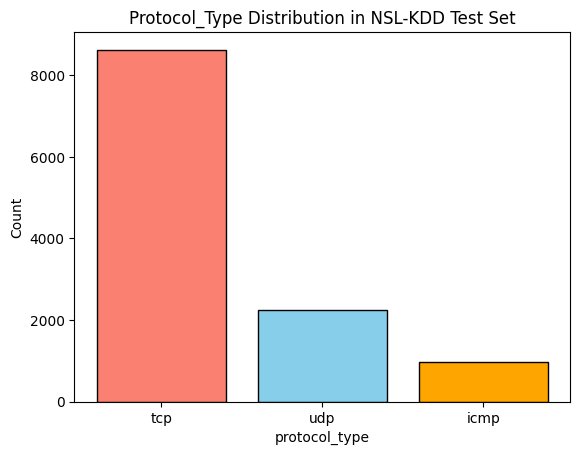

In [ ]:
cat = test['protocol_type'].unique()
plt.bar(cat, vals, color=['salmon', 'skyblue', 'orange'], edgecolor = 'black')
plt.title('Protocol_Type Distribution in NSL-KDD Test Set')
plt.xlabel('protocol_type')
plt.ylabel('Count')
plt.show()

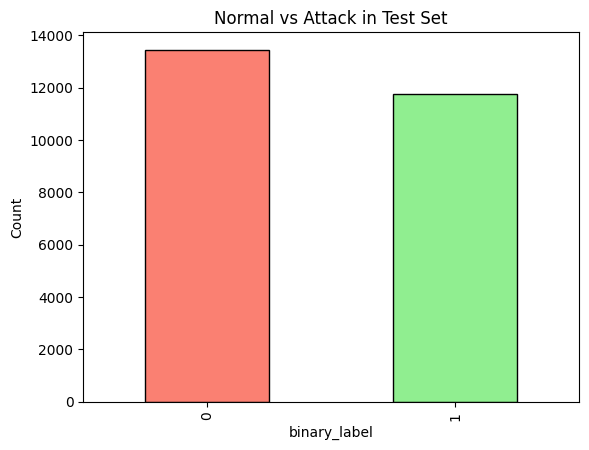

In [ ]:
test['binary_label'].value_counts().plot(kind='bar', color=['salmon', 'lightgreen'], edgecolor = 'black')
plt.title('Normal vs Attack in Test Set')
plt.ylabel('Count')
plt.show()


#### EDA and Encodings

In [ ]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (11850, 43)
Test shape: (25192, 43)


In [ ]:
categorical_features = ['protocol_type', 'service', 'flag']
# numeric_features should contain only the actual features that are not categorical.
# The 'binary_label', 'target', and 'attack_type' columns are labels and should not be treated as features.
# We use the original 'feature_names' list which contains only the input features.# Define all columns that are NOT features
labels_to_exclude = ['label', 'binary_label', 'target', 'target_name', 'difficulty']

# Create numeric_features list by filtering out both categorical and label columns
numeric_features = [
    col for col in feature_names
    if col not in categorical_features and col not in labels_to_exclude
]

In [ ]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder, FunctionTransformer

# 1. Define the specific features that need Log Transformation
# These features have values ranging from 0 to millions
log_features = ['duration', 'src_bytes', 'dst_bytes']

# 2. Identify remaining numeric features and categorical features
# (Assuming numeric_features and categorical_features are already defined in your notebook)
other_numeric = [f for f in numeric_features if f not in log_features]

# 3. Create a sub-pipeline for the log-transformed features
# FunctionTransformer(np.log1p) calculates log(1 + x) to handle zero values
log_pipeline = Pipeline(steps=[
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', RobustScaler())
])

# 4. Create the updated ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        # Apply Log + Robust Scaling to high-variance features
        ('log_vars', log_pipeline, log_features),

        # Apply Robust Scaling to the rest of the numeric features
        ('num_vars', RobustScaler(), other_numeric),

        # Keep your existing One-Hot Encoding for categorical features
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 5. Integrate into your final model pipeline
# Replace 'tuned_xgb' with your chosen model
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', tuned_xgb)
])

# Now you can fit the pipeline as usual
# final_pipeline.fit(X_train, y_train)

In [ ]:
rf_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=400,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=3,
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=42
    ))
])

In [ ]:
xgb_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', xgb.XGBClassifier(
        n_estimators=400,
        max_depth=10,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(train['binary_label'].value_counts()[0] / train['binary_label'].value_counts()[1]),
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    ))
])

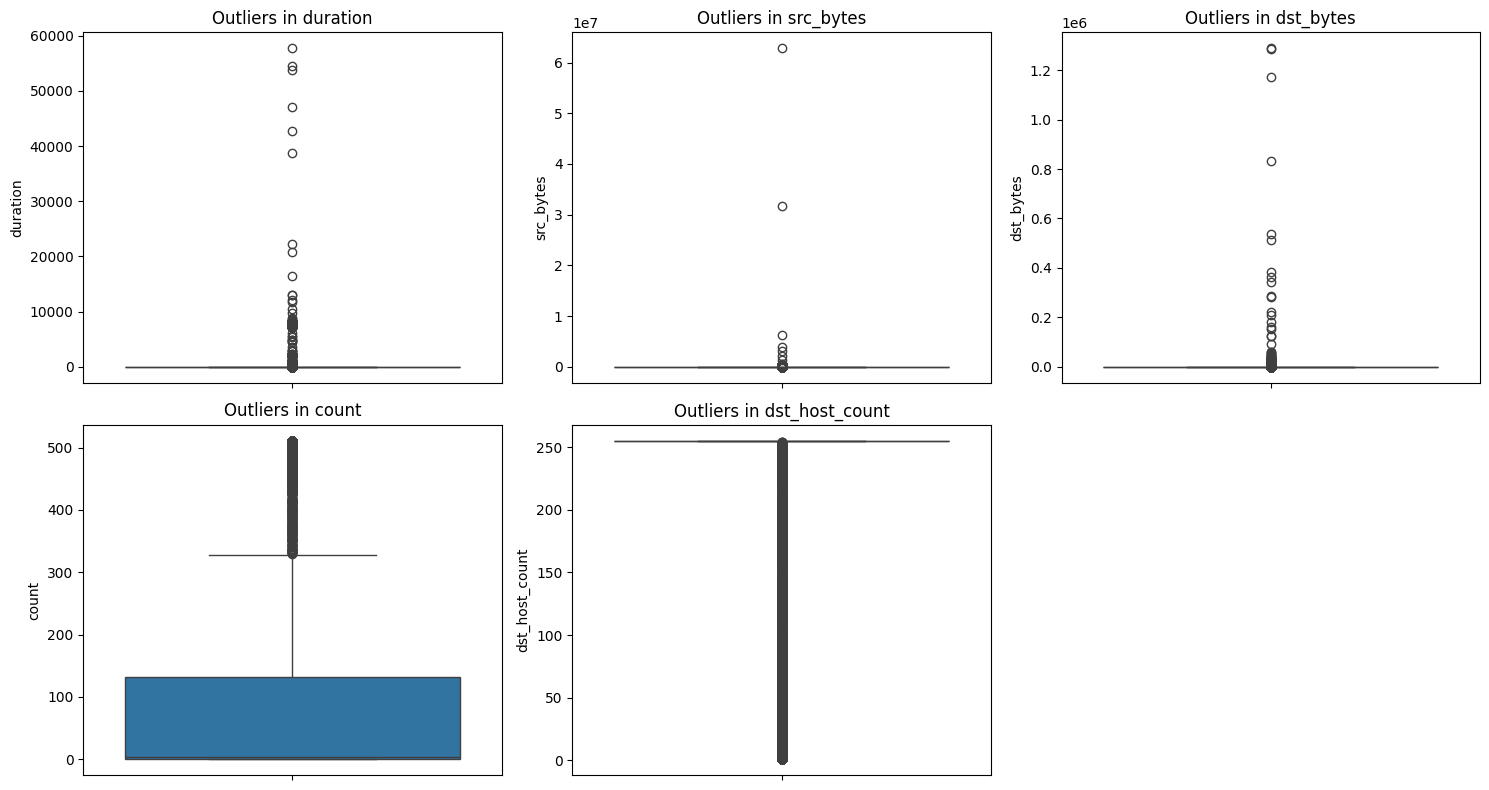

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select key numeric features to check for outliers
outlier_features = ['duration', 'src_bytes', 'dst_bytes', 'count', 'dst_host_count']

plt.figure(figsize=(15, 8))
for i, col in enumerate(outlier_features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=train[col])
    plt.title(f'Outliers in {col}')
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats

# Calculate Z-scores for numeric columns
numeric_cols = train.select_dtypes(include=[np.number]).columns
z_scores = np.abs(stats.zscore(train[numeric_cols]))

# Identify rows where any feature has a Z-score > 3
outliers = train[(z_scores > 3).any(axis=1)]
print(f"Total outliers detected: {len(outliers)}")

Total outliers detected: 4020


In [ ]:
Q1 = train[numeric_cols].quantile(0.25)
Q3 = train[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Define outliers as points outside 1.5 * IQR
outlier_mask = (train[numeric_cols] < (Q1 - 1.5 * IQR)) | (train[numeric_cols] > (Q3 + 1.5 * IQR))
print(outlier_mask.sum()) # See outlier count per feature

duration                       2743
src_bytes                      2387
dst_bytes                      1670
land                              7
wrong_fragment                  100
urgent                           10
hot                             985
num_failed_logins               478
logged_in                         0
num_compromised                 368
root_shell                       51
su_attempted                      4
num_root                         47
num_file_creations               38
num_shells                       19
num_access_files                 38
num_outbound_cmds                 0
is_host_login                    11
is_guest_login                  627
count                          1275
srv_count                      2080
serror_rate                    2200
srv_serror_rate                1843
rerror_rate                       0
srv_rerror_rate                   0
same_srv_rate                     0
diff_srv_rate                  1979
srv_diff_host_rate          

In [ ]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder, FunctionTransformer

# In your ColumnTransformer definition:

# 1. Define the specific features that need Log Transformation
# These features have values ranging from 0 to millions
log_features = ['duration', 'src_bytes', 'dst_bytes']

# 2. Identify remaining numeric features and categorical features
# (Assuming numeric_features and categorical_features are already defined in your notebook)
other_numeric = [f for f in numeric_features if f not in log_features]

# 3. Create a sub-pipeline for the log-transformed features
# FunctionTransformer(np.log1p) calculates log(1 + x) to handle zero values
log_pipeline = Pipeline(steps=[
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', RobustScaler())
])

# 4. Create the updated ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        # Apply Log + Robust Scaling to high-variance features
        ('log_vars', log_pipeline, log_features),

        # Apply Robust Scaling to the rest of the numeric features
        ('num_vars', RobustScaler(), other_numeric),

        # Keep your existing One-Hot Encoding for categorical features
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [ ]:
# Filter out rows where 'attack_type' is null from the training set,
# as LabelEncoder might treat NaN as a separate, very small class,
# leading to SMOTE errors.
train_cleaned = train.dropna(subset=['attack_type'])

X_train_raw = train_cleaned[feature_names] # Select only actual features
y_train_binary = train_cleaned['binary_label']
y_train_multi = train_cleaned['target']

X_test_raw = test[feature_names] # Select only actual features
y_test_binary = test['binary_label']
y_test_multi = test['target']

# Preprocess (This uses your preprocessor from Cell 27)
X_train_preprocessed = preprocessor.fit_transform(X_train_raw)
X_test_preprocessed = preprocessor.transform(X_test_raw)

# Apply SMOTE for the multi-class problem
smote = SMOTE(random_state=42)
X_train_resampled_multi, y_train_resampled_multi = smote.fit_resample(X_train_preprocessed, y_train_multi)

print(f"Original X_train features shape: {X_train_raw.shape}")
print(f"Preprocessed X_train features shape: {X_train_preprocessed.shape}")
print(f"Resampled X_train features for multi-class shape: {X_train_resampled_multi.shape}")
print(f"Original y_train_multi value counts:\n{y_train_multi.value_counts()}")
print(f"Resampled y_train_multi value counts:\n{y_train_resampled_multi.value_counts()}")

# Train the tuned_xgb model (multi-class) with the resampled, preprocessed data
tuned_xgb = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    random_state=42
)
tuned_xgb.fit(X_train_resampled_multi, y_train_resampled_multi)

# Evaluate tuned_xgb
y_pred_multi = tuned_xgb.predict(X_test_preprocessed) # Predict on preprocessed test data
print("\nAccuracy Of Tuned XGB (Multi-class):", accuracy_score(y_test_multi, y_pred_multi))
print(classification_report(y_test_multi, y_pred_multi))



Original X_train features shape: (11848, 41)
Preprocessed X_train features shape: (11848, 114)
Resampled X_train features for multi-class shape: (21710, 114)
Original y_train_multi value counts:
target
0    4342
3    2885
2    2402
1    2152
4      67
Name: count, dtype: int64
Resampled y_train_multi value counts:
target
3    4342
0    4342
1    4342
2    4342
4    4342
Name: count, dtype: int64

Accuracy Of Tuned XGB (Multi-class): 0.9299380755795491
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      9234
           1       0.94      0.93      0.94     13449
           2       0.82      0.81      0.81      2289
           3       0.09      0.17      0.11       209
           4       0.13      0.82      0.22        11

    accuracy                           0.93     25192
   macro avg       0.59      0.74      0.61     25192
weighted avg       0.94      0.93      0.93     25192



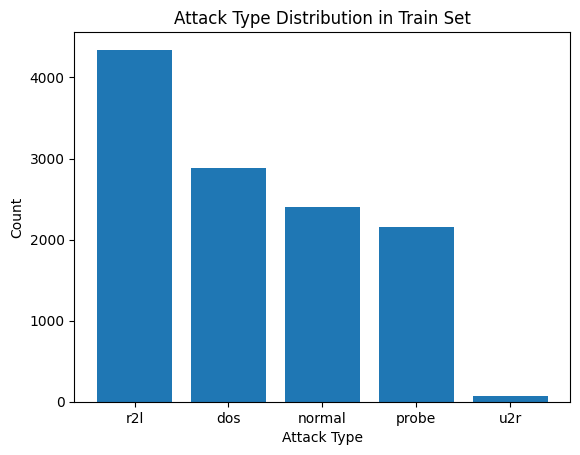

In [ ]:
vals = train['attack_type'].value_counts()
cats = train['attack_type'].dropna().unique() # Filter out NaN values

plt.bar(cats, vals)
plt.title('Attack Type Distribution in Train Set')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.show()


In [ ]:
import shap

In [ ]:
xgb_clf = tuned_xgb

In [ ]:
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test_preprocessed)

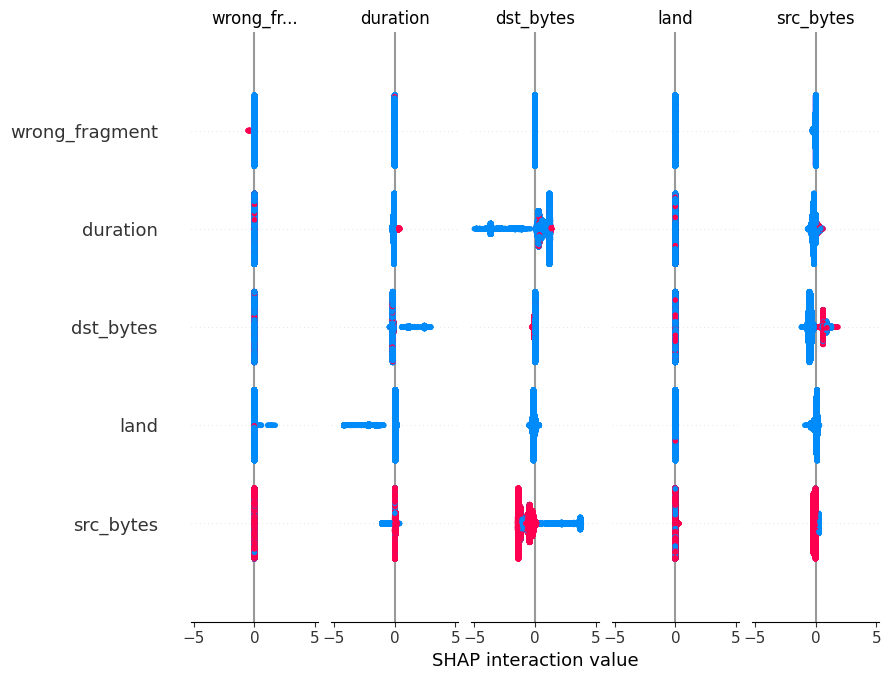

In [ ]:
shap.summary_plot(shap_values, X_test_preprocessed, feature_names=np.concatenate(
    [numeric_features, preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)]
))

In [ ]:
import joblib

# Save the trained models
joblib.dump(tuned_xgb, 'tuned_xgb_model.pkl')
print("Models saved successfully!")

Models saved successfully!
